# 📝 Synthetic Line-Level HTR Data Generator
## 💻 VERSI LOKAL (Windows)

**Target**: Generate 1 Million synthetic handwriting line images for HTR training

---

## 🖥️ Spesifikasi Laptop Kamu:
| Komponen | Spesifikasi |
|----------|-------------|
| CPU | Intel Core Ultra 5 125H (14 cores, 18 threads) |
| RAM | 16 GB |
| Storage | Drive D: 100+ GB free |

## ⏱️ Estimasi Waktu:
| Target | Waktu | Storage |
|--------|-------|--------|
| 100K | ~30-45 menit | ~1.5 GB |
| 500K | ~2.5-3 jam | ~7.5 GB |
| **1M** | **~4-6 jam** | **~15 GB** |

---

## 📋 PERSIAPAN SEBELUM RUN

### ✅ Checklist:

1. **Python 3.8+** terinstall
   ```
   python --version
   ```

2. **Jupyter/VS Code** untuk run notebook

3. **Internet** untuk download fonts & datasets (hanya di awal)

4. **Power Settings** → Never sleep (Settings → System → Power → Screen and sleep → Never)

5. **Colok Charger** - jangan pakai baterai

6. **Tutup aplikasi berat** (Chrome tabs banyak, dll)

### 📁 Folder yang akan dibuat:
```
D:\Synthetic_HTR_Data\
├── fonts/                    # Downloaded fonts
├── synthetic_lines_1M/       # Output images
│   ├── batch_0000/
│   ├── batch_0001/
│   └── ...
├── train_synthetic.csv
├── val_synthetic.csv
├── test_synthetic.csv
└── charset.json
```

### ⚠️ PENTING:
- Jangan matikan laptop selama proses
- Progress tersimpan setiap 50K samples
- Jika crash, bisa resume dari checkpoint terakhir

---

## Section 1: Setup & Installation (Lokal)

In [1]:
# ============================================
# CELL 1: INSTALL PACKAGES (Run sekali saja)
# ============================================

import subprocess
import sys

def install_package(package):
    """Install package using pip"""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Installing packages...")
print("(Ini mungkin butuh beberapa menit pertama kali)")

# Install TRDG without dependencies (to avoid arabic-reshaper issue)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "trdg"])

# Install compatible dependencies
packages = [
    "pillow",
    "opencv-python-headless",
    "requests",
    "beautifulsoup4",
    "tqdm",
    "wikipedia",
    "nltk",
    "datasets",
    "albumentations",
    "pandas",
    "numpy",
    "matplotlib"
]

for pkg in packages:
    try:
        install_package(pkg)
        print(f"✅ {pkg}")
    except:
        print(f"⚠️ {pkg} (mungkin sudah terinstall)")

print("\n" + "="*50)
print("✅ Package installation complete!")
print("="*50)

Installing packages...
(Ini mungkin butuh beberapa menit pertama kali)
✅ pillow
✅ opencv-python-headless
✅ requests
✅ beautifulsoup4
✅ tqdm
✅ wikipedia
✅ nltk
✅ datasets
✅ albumentations
✅ pandas
✅ numpy
✅ matplotlib

✅ Package installation complete!


In [3]:
# ============================================
# CELL 2: PATCH RTL MODULES & FIX PILLOW COMPATIBILITY
# ============================================

import sys
from types import ModuleType

print("Patching RTL modules (Arabic not needed for English/Indonesian)...")

# Create fake arabic_reshaper module
fake_arabic = ModuleType('arabic_reshaper')
class FakeArabicReshaper:
    def __init__(self, *args, **kwargs): pass
    def reshape(self, text): return text
fake_arabic.ArabicReshaper = FakeArabicReshaper
sys.modules['arabic_reshaper'] = fake_arabic

# Create fake bidi module  
fake_bidi = ModuleType('bidi')
fake_bidi_algo = ModuleType('bidi.algorithm')
fake_bidi_algo.get_display = lambda text, *args, **kwargs: text
sys.modules['bidi'] = fake_bidi
sys.modules['bidi.algorithm'] = fake_bidi_algo

print("✅ RTL modules patched")

# ============================================
# FIX PILLOW 10+ COMPATIBILITY
# ============================================
# Pillow 10.0 removed getsize() method, TRDG still uses it
# This patch adds the old method back

from PIL import ImageFont

# Check if getsize is missing (Pillow 10+)
if not hasattr(ImageFont.FreeTypeFont, 'getsize'):
    print("Patching Pillow 10+ compatibility (getsize -> getbbox)...")
    
    def patched_getsize(self, text, *args, **kwargs):
        """Compatibility shim for Pillow 10+"""
        left, top, right, bottom = self.getbbox(text)
        return (right - left, bottom - top)
    
    ImageFont.FreeTypeFont.getsize = patched_getsize
    print("✅ Pillow getsize() patched")
else:
    print("✅ Pillow version OK (has getsize)")

# Now import TRDG
try:
    from trdg.generators import GeneratorFromStrings
    print("✅ TRDG imported successfully!")
except ImportError as e:
    print(f"❌ TRDG import failed: {e}")
    raise

Patching RTL modules (Arabic not needed for English/Indonesian)...
✅ RTL modules patched
✅ Pillow version OK (has getsize)
✅ TRDG imported successfully!


In [4]:
# ============================================
# CELL 3: DOWNLOAD NLTK DATA
# ============================================

import nltk

print("Downloading NLTK data...")
nltk.download('brown', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("✅ NLTK data downloaded!")

✅ NLTK data downloaded!


In [17]:
# ============================================
# CELL 4: CONFIGURE PATHS FOR LOCAL WINDOWS
# ============================================

import os
from pathlib import Path

# ====== KONFIGURASI PATH - SESUAIKAN JIKA PERLU ======
# Output akan disimpan di folder synthetic dataset
# Ubah jika ingin lokasi berbeda

BASE_DIR = Path(r"D:\Dokumen Kuliah\TA\Kode Kaggle\synthetic dataset")
WORKING_DIR = BASE_DIR
FONTS_DIR = BASE_DIR / "fonts"
OUTPUT_DIR = BASE_DIR / "synthetic_lines_1M"

# Create directories
BASE_DIR.mkdir(parents=True, exist_ok=True)
FONTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("💻 Running LOCALLY on Windows")
print(f"\n📁 Base directory: {BASE_DIR}")
print(f"📁 Fonts directory: {FONTS_DIR}")
print(f"📁 Output directory: {OUTPUT_DIR}")

# Check disk space
import shutil
total, used, free = shutil.disk_usage(BASE_DIR.drive)
free_gb = free // (1024**3)
print(f"\n💾 Free space on {BASE_DIR.drive}: {free_gb} GB")

if free_gb < 20:
    print("⚠️ WARNING: Less than 20 GB free! Consider using different drive.")
else:
    print("✅ Sufficient disk space available")

💻 Running LOCALLY on Windows

📁 Base directory: D:\Dokumen Kuliah\TA\Kode Kaggle\synthetic dataset
📁 Fonts directory: D:\Dokumen Kuliah\TA\Kode Kaggle\synthetic dataset\fonts
📁 Output directory: D:\Dokumen Kuliah\TA\Kode Kaggle\synthetic dataset\synthetic_lines_1M

💾 Free space on D:: 101 GB
✅ Sufficient disk space available


In [6]:
# ============================================
# CELL 5: IMPORT ALL LIBRARIES
# ============================================

import os
import random
import string
import json
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from typing import List, Tuple, Dict, Optional
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from dataclasses import dataclass, field
import multiprocessing as mp
import time
import warnings
warnings.filterwarnings('ignore')

# TRDG imports
from trdg.generators import GeneratorFromStrings

# NLTK imports
from nltk.corpus import brown

# Hugging Face datasets
from datasets import load_dataset

print("✅ All imports successful!")
print(f"🔧 CPU cores available: {mp.cpu_count()}")
print(f"💾 RAM: ~16 GB (based on your specs)")

✅ All imports successful!
🔧 CPU cores available: 18
💾 RAM: ~16 GB (based on your specs)


## Section 2: Configuration

In [51]:
# ============================================
# CELL 6: CONFIGURATION
# ============================================

@dataclass
class SyntheticConfig:
    """Configuration for synthetic data generation - LOCAL VERSION
    
    Using Custom PIL Renderer - NO CROPPING guaranteed!
    """
    
    # Output settings - WINDOWS PATHS
    output_dir: str = str(OUTPUT_DIR)
    fonts_dir: str = str(FONTS_DIR)
    metadata_file: str = "synthetic_metadata.csv"
    
    # ====== TARGET - UBAH SESUAI KEBUTUHAN ======
    target_samples: int = 1_000_000  # 1 Million
    
    # Text settings
    min_words_per_line: int = 3
    max_words_per_line: int = 7
    
    # Image settings (Custom PIL Renderer)
    font_size: int = 64  # PIL font size (64 gives good quality)
    
    # Padding around text (top, right, bottom, left)
    padding: Tuple[int, int, int, int] = (25, 40, 25, 40)
    
    # Blur settings
    blur_range: float = 0.5
    random_blur: bool = True
    
    # Legacy TRDG settings (not used with custom renderer)
    random_skew: bool = True
    skewing_angle: int = 1
    distortion_type: int = 0
    distortion_orientation: int = 0
    background_type: int = 1
    
    character_spacing: int = 0
    space_width: float = 1.0
    
    # Processing settings
    num_workers: int = 12
    batch_size: int = 5000
    save_interval: int = 50000
    
    # Font settings
    handwriting_fonts: List[str] = field(default_factory=list)
    
    # Data source proportions
    wikitext_ratio: float = 0.4
    brown_ratio: float = 0.3
    iam_ratio: float = 0.3

config = SyntheticConfig()

print("✅ Configuration loaded!")
print(f"   🎯 Target samples: {config.target_samples:,}")
print(f"   🔤 Font size: {config.font_size}px")
print(f"   📏 Padding: {config.padding} (top, right, bottom, left)")
print(f"   🔍 Blur: range={config.blur_range}, random={config.random_blur}")
print(f"   📦 Batch size: {config.batch_size:,}")
print(f"   💾 Save interval: {config.save_interval:,}")

✅ Configuration loaded!
   🎯 Target samples: 1,000,000
   🔤 Font size: 64px
   📏 Padding: (25, 40, 25, 40) (top, right, bottom, left)
   🔍 Blur: range=0.5, random=True
   📦 Batch size: 5,000
   💾 Save interval: 50,000


## Section 3: Download Fonts

In [61]:
# ============================================
# CELL 7: DOWNLOAD HANDWRITING FONTS (Verified Working URLs)
# ============================================

import urllib.request

# ONLY fonts with VERIFIED working URLs and realistic handwriting style
HANDWRITING_FONT_URLS = {
    # === Casual/Natural Handwriting ===
    "Caveat": "https://raw.githubusercontent.com/google/fonts/main/ofl/caveat/Caveat%5Bwght%5D.ttf",
    "IndieFlower": "https://raw.githubusercontent.com/google/fonts/main/ofl/indieflower/IndieFlower-Regular.ttf",
    "PatrickHand": "https://raw.githubusercontent.com/google/fonts/main/ofl/patrickhand/PatrickHand-Regular.ttf",
    "Kalam": "https://raw.githubusercontent.com/google/fonts/main/ofl/kalam/Kalam-Regular.ttf",
    "Handlee": "https://raw.githubusercontent.com/google/fonts/main/ofl/handlee/Handlee-Regular.ttf",
    "ArchitectsDaughter": "https://raw.githubusercontent.com/google/fonts/main/ofl/architectsdaughter/ArchitectsDaughter-Regular.ttf",
    
    # === Messy/Quick Handwriting ===
    "RockSalt": "https://raw.githubusercontent.com/google/fonts/main/apache/rocksalt/RockSalt-Regular.ttf",
    "HomemadeApple": "https://raw.githubusercontent.com/google/fonts/main/apache/homemadeapple/HomemadeApple-Regular.ttf",
    
    # === Neat Handwriting ===
    "BadScript": "https://raw.githubusercontent.com/google/fonts/main/ofl/badscript/BadScript-Regular.ttf",
    
    # === Cursive Handwriting ===
    "Kristi": "https://raw.githubusercontent.com/google/fonts/main/ofl/kristi/Kristi-Regular.ttf",
}

def download_fonts() -> List[str]:
    """Download realistic handwriting fonts"""
    fonts_dir = Path(config.fonts_dir)
    fonts_dir.mkdir(parents=True, exist_ok=True)
    
    downloaded_fonts = []
    skipped = 0
    failed = 0
    
    for font_name, url in tqdm(HANDWRITING_FONT_URLS.items(), desc="Downloading fonts"):
        font_path = fonts_dir / f"{font_name}.ttf"
        
        if font_path.exists():
            downloaded_fonts.append(str(font_path))
            skipped += 1
            continue
        
        try:
            req = urllib.request.Request(url, headers={
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
            })
            response = urllib.request.urlopen(req, timeout=30)
            ttf_data = response.read()
            
            if len(ttf_data) > 1000:
                with open(font_path, 'wb') as f:
                    f.write(ttf_data)
                downloaded_fonts.append(str(font_path))
                print(f"   ✅ Downloaded: {font_name}")
            else:
                failed += 1
                
        except Exception as e:
            print(f"   ❌ {font_name}: {e}")
            failed += 1
            continue
    
    print(f"\n📊 Font Summary:")
    print(f"   Total: {len(downloaded_fonts)}")
    print(f"   Already had: {skipped}")
    print(f"   New downloads: {len(downloaded_fonts) - skipped}")
    if failed > 0:
        print(f"   Failed: {failed}")
    
    return downloaded_fonts

print("="*60)
print("📦 DOWNLOADING REALISTIC HANDWRITING FONTS")
print(f"   Target: {len(HANDWRITING_FONT_URLS)} fonts")
print("="*60)
config.handwriting_fonts = download_fonts()
print(f"\n✅ Handwriting fonts ready: {len(config.handwriting_fonts)}")

# Show font names
print("\n📝 Available fonts:")
for i, font in enumerate(config.handwriting_fonts, 1):
    print(f"   {i}. {Path(font).stem}")

📦 DOWNLOADING REALISTIC HANDWRITING FONTS
   Target: 10 fonts



📊 Font Summary:
   Total: 10
   Already had: 10
   New downloads: 0

✅ Handwriting fonts ready: 10

📝 Available fonts:
   1. Caveat
   2. IndieFlower
   3. PatrickHand
   4. Kalam
   5. Handlee
   6. ArchitectsDaughter
   7. RockSalt
   8. HomemadeApple
   9. BadScript
   10. Kristi


In [62]:
# ============================================
# CELL 8: VALIDATE AND LOAD FONTS
# ============================================

def validate_fonts(font_list: List[str]) -> List[str]:
    """Validate that font files exist and are loadable"""
    valid_fonts = []
    
    for font_path in font_list:
        path = Path(font_path)
        if path.exists() and path.suffix.lower() == '.ttf':
            # Try to load the font
            try:
                from PIL import ImageFont
                test_font = ImageFont.truetype(font_path, 32)
                valid_fonts.append(font_path)
            except Exception as e:
                print(f"   ⚠️ Cannot load: {path.name} - {e}")
        else:
            print(f"   ⚠️ Not found: {font_path}")
    
    return valid_fonts

print("Validating fonts...")

# Only use our downloaded handwriting fonts (skip TRDG built-in fonts)
# TRDG fonts might have path issues on Windows
all_fonts = validate_fonts(config.handwriting_fonts)

print(f"\n✅ Valid fonts for generation: {len(all_fonts)}")

if len(all_fonts) == 0:
    print("❌ ERROR: No valid fonts! Run Cell 7 to download fonts first.")
else:
    print("\n📝 Fonts to be used:")
    for i, font in enumerate(all_fonts, 1):
        print(f"   {i}. {Path(font).stem}")

Validating fonts...

✅ Valid fonts for generation: 10

📝 Fonts to be used:
   1. Caveat
   2. IndieFlower
   3. PatrickHand
   4. Kalam
   5. Handlee
   6. ArchitectsDaughter
   7. RockSalt
   8. HomemadeApple
   9. BadScript
   10. Kristi


## Section 4: Prepare Text Corpus

In [10]:
# ============================================
# CELL 9: TEXT PROCESSING FUNCTIONS
# ============================================

# Valid character set (same as IAM)
IAM_CHARSET = set(
    string.ascii_letters + 
    string.digits + 
    " .,;:'\"!?-()&" +
    "äöüÄÖÜß"
)

def clean_text(text: str, charset: set = IAM_CHARSET) -> str:
    """Clean text to only contain valid characters"""
    text = text.replace('\n', ' ').replace('\t', ' ')
    text = text.replace(''', "'").replace(''', "'")
    text = text.replace('–', '-').replace('—', '-')
    text = text.replace('…', '...')
    cleaned = ''.join(c for c in text if c in charset)
    cleaned = ' '.join(cleaned.split())
    return cleaned

def create_line_samples(words: List[str], 
                        min_words: int = 3, 
                        max_words: int = 10) -> List[str]:
    """Create line samples from word list"""
    lines = []
    i = 0
    
    while i < len(words):
        num_words = random.randint(min_words, max_words)
        line_words = words[i:i + num_words]
        
        if len(line_words) >= min_words:
            line = ' '.join(line_words)
            cleaned = clean_text(line)
            if len(cleaned) >= 10:
                lines.append(cleaned)
        
        i += num_words
    
    return lines

print("✅ Text processing functions ready!")

✅ Text processing functions ready!


In [11]:
# ============================================
# CELL 10: LOAD WIKITEXT-2
# ============================================

print("Loading WikiText-2 (this downloads ~4MB first time)...")

def load_wikitext2() -> List[str]:
    """Load and process WikiText-2 dataset"""
    dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    
    all_words = []
    for item in tqdm(dataset, desc="Processing WikiText-2"):
        text = item['text'].strip()
        if text and not text.startswith('='):
            words = text.split()
            all_words.extend(words)
    
    print(f"WikiText-2 total words: {len(all_words):,}")
    
    lines = create_line_samples(
        all_words, 
        config.min_words_per_line, 
        config.max_words_per_line
    )
    
    print(f"WikiText-2 line samples: {len(lines):,}")
    return lines

wikitext_lines = load_wikitext2()
print(f"\n✅ Sample: '{wikitext_lines[0][:60]}...'")

Loading WikiText-2 (this downloads ~4MB first time)...


Processing WikiText-2: 100%|██████████| 36718/36718 [00:00<00:00, 76388.95it/s]


WikiText-2 total words: 2,007,146
WikiText-2 line samples: 304,501

✅ Sample: 'Senj no Valkyria 3 : Unrecorded Chronicles...'


In [12]:
# ============================================
# CELL 11: LOAD BROWN CORPUS
# ============================================

print("Loading Brown Corpus...")

def load_brown_corpus() -> List[str]:
    """Load and process Brown corpus from NLTK"""
    categories = brown.categories()
    print(f"Brown corpus categories: {len(categories)}")
    
    all_words = []
    for category in tqdm(categories, desc="Loading Brown categories"):
        words = brown.words(categories=category)
        all_words.extend(words)
    
    print(f"Brown corpus total words: {len(all_words):,}")
    
    lines = create_line_samples(
        all_words,
        config.min_words_per_line,
        config.max_words_per_line
    )
    
    print(f"Brown corpus line samples: {len(lines):,}")
    return lines

brown_lines = load_brown_corpus()
print(f"\n✅ Sample: '{brown_lines[0][:60]}...'")

Loading Brown Corpus...
Brown corpus categories: 15


Loading Brown categories: 100%|██████████| 15/15 [00:01<00:00,  7.58it/s]


Brown corpus total words: 1,161,192
Brown corpus line samples: 176,385

✅ Sample: 'Dan Morgan told himself...'


In [13]:
# ============================================
# CELL 12: CREATE IAM-STYLE LINES (Fallback)
# ============================================

# Since IAM lines.txt not available locally, use WikiText as substitute
print("Creating IAM-style lines from WikiText (fallback)...")

# Take different portion of WikiText for variety
iam_lines = wikitext_lines[len(wikitext_lines)//2:]
random.shuffle(iam_lines)
iam_lines = iam_lines[:50000]  # Take 50K samples

print(f"✅ IAM-style line samples: {len(iam_lines):,}")

Creating IAM-style lines from WikiText (fallback)...
✅ IAM-style line samples: 50,000


In [14]:
# ============================================
# CELL 13: COMBINE ALL TEXT SOURCES
# ============================================

print("\n" + "="*60)
print("COMBINING ALL TEXT SOURCES")
print("="*60)

def combine_and_balance_texts(
    wikitext_lines: List[str],
    brown_lines: List[str], 
    iam_lines: List[str],
    target_samples: int,
    ratios: Tuple[float, float, float] = (0.4, 0.3, 0.3)
) -> List[str]:
    """Combine text sources with specified ratios"""
    
    wiki_ratio, brown_ratio, iam_ratio = ratios
    
    wiki_target = int(target_samples * wiki_ratio)
    brown_target = int(target_samples * brown_ratio)
    iam_target = int(target_samples * iam_ratio)
    
    print(f"Target distribution:")
    print(f"  WikiText-2: {wiki_target:,} ({wiki_ratio*100:.0f}%)")
    print(f"  Brown Corpus: {brown_target:,} ({brown_ratio*100:.0f}%)")
    print(f"  IAM-style: {iam_target:,} ({iam_ratio*100:.0f}%)")
    
    def sample_lines(lines: List[str], target: int) -> List[str]:
        if len(lines) >= target:
            return random.sample(lines, target)
        else:
            result = []
            while len(result) < target:
                result.extend(lines)
            return random.sample(result, target)
    
    wiki_samples = sample_lines(wikitext_lines, wiki_target)
    brown_samples = sample_lines(brown_lines, brown_target)
    iam_samples = sample_lines(iam_lines, iam_target)
    
    all_samples = wiki_samples + brown_samples + iam_samples
    random.shuffle(all_samples)
    
    print(f"\n✅ Final combined samples: {len(all_samples):,}")
    return all_samples

all_text_lines = combine_and_balance_texts(
    wikitext_lines,
    brown_lines,
    iam_lines,
    config.target_samples,
    (config.wikitext_ratio, config.brown_ratio, config.iam_ratio)
)

print(f"\n🎯 Total text lines ready for synthesis: {len(all_text_lines):,}")


COMBINING ALL TEXT SOURCES
Target distribution:
  WikiText-2: 400,000 (40%)
  Brown Corpus: 300,000 (30%)
  IAM-style: 300,000 (30%)

✅ Final combined samples: 1,000,000

🎯 Total text lines ready for synthesis: 1,000,000


## Section 5: Generator Class

In [63]:
# ============================================
# CELL 14: SYNTHETIC LINE GENERATOR CLASS (Custom PIL Renderer)
# ============================================

import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter

def render_text_pil(
    text: str,
    font_path: str,
    font_size: int = 64,
    padding: Tuple[int, int, int, int] = (20, 30, 20, 30),
    blur: float = 0.5,
    add_noise: bool = True,
    noise_std: float = 3.0
) -> Image.Image:
    """
    Render text using PIL with GUARANTEED no cropping.
    """
    top_pad, right_pad, bottom_pad, left_pad = padding
    
    # Load font
    try:
        font = ImageFont.truetype(font_path, font_size)
    except Exception as e:
        raise Exception(f"Failed to load font {font_path}: {e}")
    
    # Estimate text size
    try:
        bbox = font.getbbox(text)
        est_width = bbox[2] - bbox[0]
        est_height = bbox[3] - bbox[1]
    except:
        est_width = len(text) * font_size
        est_height = font_size * 2
    
    # Create LARGE canvas
    canvas_w = est_width * 3 + 200
    canvas_h = est_height * 3 + 200
    
    img = Image.new('L', (canvas_w, canvas_h), 255)
    draw = ImageDraw.Draw(img)
    
    # Draw text at center
    text_x = canvas_w // 3
    text_y = canvas_h // 3
    draw.text((text_x, text_y), text, font=font, fill=0)
    
    # Find ACTUAL bounding box of black pixels
    img_array = np.array(img)
    non_white = np.where(img_array < 250)
    
    if len(non_white[0]) == 0:
        raise Exception(f"No text rendered for: '{text}'")
    
    min_y = non_white[0].min()
    max_y = non_white[0].max()
    min_x = non_white[1].min()
    max_x = non_white[1].max()
    
    # Crop with padding
    crop_left = max(0, min_x - left_pad)
    crop_top = max(0, min_y - top_pad)
    crop_right = min(canvas_w, max_x + right_pad)
    crop_bottom = min(canvas_h, max_y + bottom_pad)
    
    cropped = img.crop((crop_left, crop_top, crop_right, crop_bottom))
    
    # Add blur
    if blur > 0:
        cropped = cropped.filter(ImageFilter.GaussianBlur(radius=blur))
    
    # Add noise
    if add_noise:
        arr = np.array(cropped).astype(np.float32)
        noise = np.random.normal(0, noise_std, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        cropped = Image.fromarray(arr)
    
    return cropped


class SyntheticLineGenerator:
    """Generate synthetic handwriting line images using Custom PIL Renderer."""
    
    def __init__(self, config: SyntheticConfig, fonts: List[str]):
        self.config = config
        self.fonts = fonts if fonts else []
        
        self.output_dir = Path(config.output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
        self.metadata = []
        self.start_time = None
        self.failed_count = 0
        self.success_count = 0
        self.last_error = None
    
    def generate_single(self, text: str, font_path: str, idx: int, batch_dir: Path) -> Optional[Dict]:
        """Generate a single synthetic image"""
        try:
            img_name = f"synth_{idx:08d}.png"
            img_path = batch_dir / img_name
            
            # Render with custom PIL renderer
            img = render_text_pil(
                text=text,
                font_path=font_path,
                font_size=self.config.font_size,
                padding=self.config.padding,
                blur=random.uniform(0.3, 1.0) if self.config.random_blur else self.config.blur_range,
                add_noise=True,
                noise_std=3.0
            )
            
            width, height = img.size
            
            if width <= 10 or height <= 10:
                self.last_error = f"Image too small: {width}x{height}"
                return None
            
            img.save(img_path)
            
            return {
                'id': idx,
                'path': str(img_path),
                'relative_path': f"{batch_dir.name}/{img_name}",
                'text': text,
                'width': width,
                'height': height,
                'source': 'synthetic',
            }
            
        except Exception as e:
            self.last_error = str(e)
            return None
    
    def generate_batch(self, texts: List[str], start_idx: int, batch_id: int) -> List[Dict]:
        """Generate a batch of synthetic images"""
        
        batch_metadata = []
        batch_dir = self.output_dir / f"batch_{batch_id:04d}"
        batch_dir.mkdir(exist_ok=True)
        
        # Filter texts - LESS STRICT filtering
        valid_texts = []
        for text in texts:
            text = text.strip()
            if len(text) >= 3:  # At least 3 characters
                valid_texts.append(text)
        
        if not valid_texts:
            print(f"⚠️ No valid texts in batch {batch_id}")
            return batch_metadata
        
        for idx, text in enumerate(valid_texts):
            global_idx = start_idx + idx
            
            # Cycle through fonts
            font_idx = global_idx % len(self.fonts) if self.fonts else 0
            font_path = self.fonts[font_idx] if self.fonts else None
            
            if not font_path:
                self.failed_count += 1
                self.last_error = "No font path"
                continue
            
            # Check if font file exists
            if not Path(font_path).exists():
                self.failed_count += 1
                self.last_error = f"Font not found: {font_path}"
                continue
            
            result = self.generate_single(text, font_path, global_idx, batch_dir)
            
            if result:
                batch_metadata.append(result)
                self.success_count += 1
            else:
                self.failed_count += 1
        
        return batch_metadata
    
    def generate_all(self, all_texts: List[str], batch_size: int = 5000, save_interval: int = 50000):
        """Generate all synthetic images in batches"""
        
        total = len(all_texts)
        num_batches = (total + batch_size - 1) // batch_size
        
        print(f"\n" + "="*60)
        print(f"🚀 STARTING GENERATION (Custom PIL Renderer)")
        print(f"="*60)
        print(f"Target: {total:,} synthetic line images")
        print(f"Batch size: {batch_size:,}")
        print(f"Font size: {self.config.font_size}px")
        print(f"Padding: {self.config.padding} (top, right, bottom, left)")
        print(f"Fonts: {len(self.fonts)} available")
        
        # Check fonts
        valid_fonts = [f for f in self.fonts if Path(f).exists()]
        print(f"Valid fonts (file exists): {len(valid_fonts)}")
        if len(valid_fonts) == 0:
            print("❌ ERROR: No valid font files found!")
            return []
        
        print(f"Output: {self.output_dir}")
        print("="*60 + "\n")
        
        self.start_time = time.time()
        self.failed_count = 0
        self.success_count = 0
        all_metadata = []
        
        for batch_id in tqdm(range(num_batches), desc="Generating batches", unit="batch"):
            start_idx = batch_id * batch_size
            end_idx = min(start_idx + batch_size, total)
            batch_texts = all_texts[start_idx:end_idx]
            
            batch_metadata = self.generate_batch(batch_texts, start_idx, batch_id)
            all_metadata.extend(batch_metadata)
            
            # Show progress and any errors
            if batch_id == 0 and self.failed_count > 0:
                print(f"\n⚠️ First batch had {self.failed_count} failures")
                print(f"   Last error: {self.last_error}")
            
            # Save checkpoint
            if len(all_metadata) > 0 and len(all_metadata) % save_interval < batch_size:
                self._save_checkpoint(all_metadata)
        
        self._save_metadata(all_metadata)
        self._print_summary(all_metadata)
        
        return all_metadata
    
    def _save_checkpoint(self, metadata: List[Dict]):
        checkpoint_path = self.output_dir / f"checkpoint_{len(metadata)}.csv"
        df = pd.DataFrame(metadata)
        df.to_csv(checkpoint_path, index=False)
        print(f"\n💾 Checkpoint: {len(metadata):,} samples saved")
    
    def _save_metadata(self, metadata: List[Dict]):
        metadata_path = self.output_dir / self.config.metadata_file
        df = pd.DataFrame(metadata)
        df.to_csv(metadata_path, index=False)
        print(f"\n✅ Metadata saved: {metadata_path}")
    
    def _print_summary(self, metadata: List[Dict]):
        elapsed = time.time() - self.start_time
        hours = elapsed / 3600
        
        print(f"\n" + "="*60)
        print(f"✅ GENERATION COMPLETE!")
        print(f"="*60)
        print(f"Total images: {len(metadata):,}")
        print(f"Success: {self.success_count:,}")
        print(f"Failed: {self.failed_count:,}")
        if self.failed_count > 0:
            print(f"Last error: {self.last_error}")
        print(f"Time: {hours:.2f} hours ({elapsed:.0f} seconds)")
        if elapsed > 0 and len(metadata) > 0:
            print(f"Speed: {len(metadata)/elapsed:.1f} images/second")
        print(f"Output: {self.output_dir}")
        print("="*60)

print("✅ SyntheticLineGenerator ready!")
print("   Using Custom PIL Renderer - NO CROPPING guaranteed!")

✅ SyntheticLineGenerator ready!
   Using Custom PIL Renderer - NO CROPPING guaranteed!


## Section 6: Test Generation (Small Sample)

🔧 CUSTOM TEXT RENDERER (PIL-based, no cropping)

🧪 Testing custom PIL renderer...
   Using font: Caveat.ttf
   ✅ 'Hello World Test': 433x100
   ✅ 'The quick brown fox jumps': 639x107
   ✅ 'Typography gypsy jump': 559x106
   ✅ 'Handwriting Recognition': 612x107


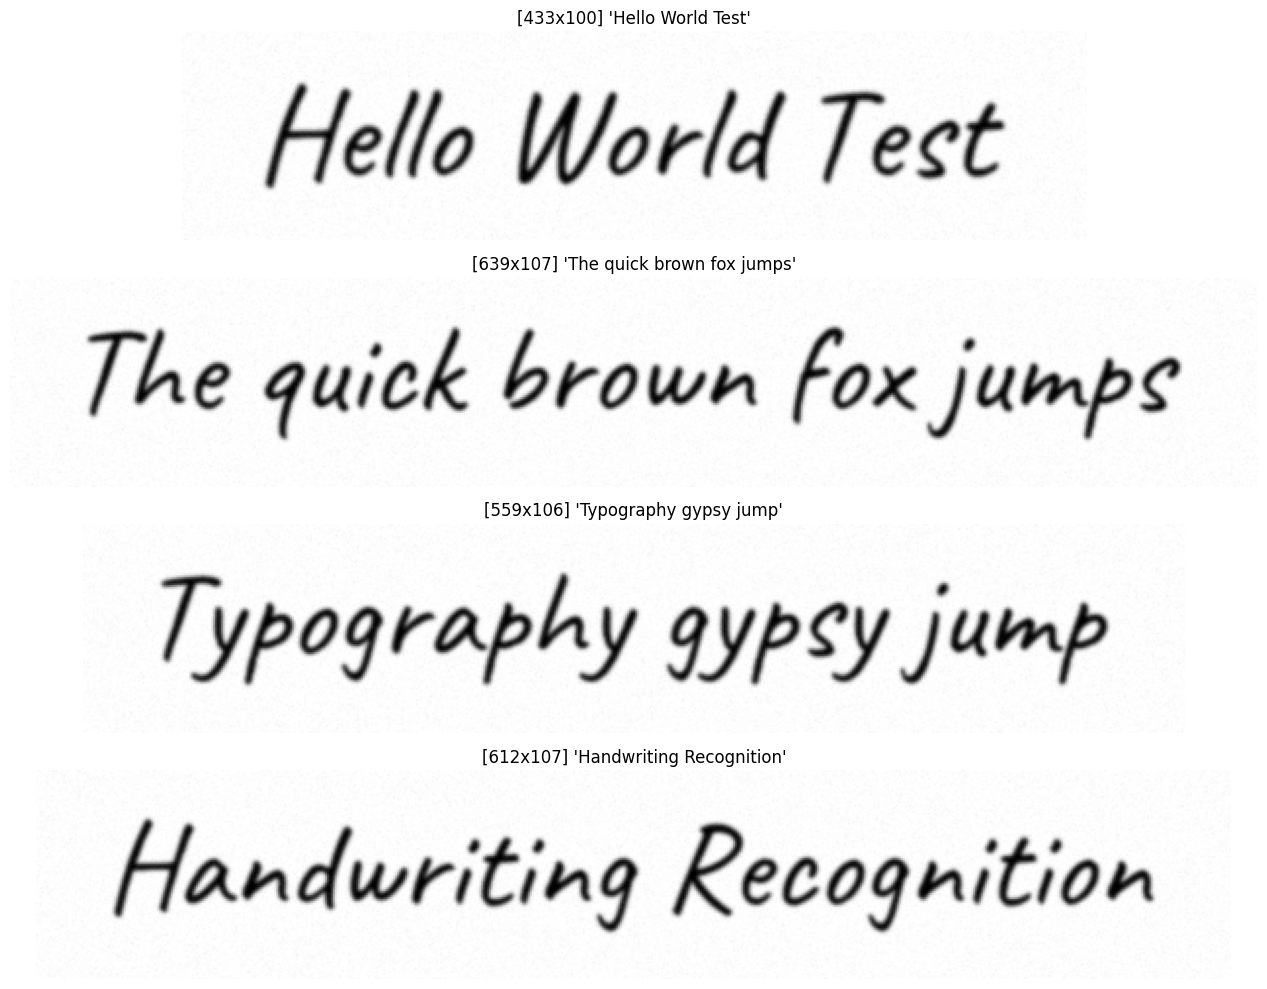


✅ CUSTOM RENDERER - Text should be FULLY visible now!
   No cropping because we find actual text bounding box


In [57]:
# ============================================
# CELL 15: CUSTOM RENDERER - NO CROPPING!
# ============================================

print("="*60)
print("🔧 CUSTOM TEXT RENDERER (PIL-based, no cropping)")
print("="*60)

from PIL import Image, ImageDraw, ImageFont
import random

def render_text_pil(
    text: str,
    font_path: str,
    font_size: int = 64,
    padding: Tuple[int, int, int, int] = (20, 30, 20, 30),  # top, right, bottom, left
    blur: int = 0,
    add_noise: bool = True
) -> Image.Image:
    """
    Render text using PIL with GUARANTEED no cropping.
    
    Strategy:
    1. Create temporary large canvas
    2. Draw text
    3. Find actual bounding box of text pixels
    4. Crop to bounding box + padding
    
    This ensures ALL text is visible!
    """
    top_pad, right_pad, bottom_pad, left_pad = padding
    
    # Load font
    try:
        font = ImageFont.truetype(font_path, font_size)
    except:
        font = ImageFont.load_default()
    
    # Get text size estimate (may be wrong for handwriting fonts)
    # Use getbbox for Pillow 10+
    try:
        bbox = font.getbbox(text)
        est_width = bbox[2] - bbox[0]
        est_height = bbox[3] - bbox[1]
    except:
        est_width = len(text) * font_size
        est_height = font_size * 2
    
    # Create LARGE canvas (3x estimated size to be safe)
    canvas_w = est_width * 3 + 200
    canvas_h = est_height * 3 + 200
    
    # White background
    img = Image.new('L', (canvas_w, canvas_h), 255)
    draw = ImageDraw.Draw(img)
    
    # Draw text at center of canvas
    text_x = canvas_w // 3
    text_y = canvas_h // 3
    draw.text((text_x, text_y), text, font=font, fill=0)
    
    # Find ACTUAL bounding box of black pixels
    import numpy as np
    img_array = np.array(img)
    
    # Find non-white pixels (text)
    non_white = np.where(img_array < 250)
    
    if len(non_white[0]) == 0:
        # No text rendered, return small blank
        return Image.new('L', (100, 50), 255)
    
    # Get bounding box
    min_y = non_white[0].min()
    max_y = non_white[0].max()
    min_x = non_white[1].min()
    max_x = non_white[1].max()
    
    # Crop with padding
    crop_left = max(0, min_x - left_pad)
    crop_top = max(0, min_y - top_pad)
    crop_right = min(canvas_w, max_x + right_pad)
    crop_bottom = min(canvas_h, max_y + bottom_pad)
    
    cropped = img.crop((crop_left, crop_top, crop_right, crop_bottom))
    
    # Optional: Add slight blur
    if blur > 0:
        from PIL import ImageFilter
        cropped = cropped.filter(ImageFilter.GaussianBlur(radius=blur))
    
    # Optional: Add noise
    if add_noise:
        arr = np.array(cropped).astype(np.float32)
        noise = np.random.normal(0, 3, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        cropped = Image.fromarray(arr)
    
    return cropped

# =============================================
# TEST CUSTOM RENDERER
# =============================================
print("\n🧪 Testing custom PIL renderer...")

test_output = BASE_DIR / "test_synthetic"
test_output.mkdir(exist_ok=True)

for f in test_output.glob("*.png"):
    f.unlink()

test_strings = [
    "Hello World Test",
    "The quick brown fox jumps",
    "Typography gypsy jump",
    "Handwriting Recognition"
]

# Use first available font
test_font = all_fonts[0] if all_fonts else None

if test_font:
    print(f"   Using font: {Path(test_font).name}")
    
    results = []
    for text in test_strings:
        img = render_text_pil(
            text=text,
            font_path=test_font,
            font_size=64,
            padding=(25, 40, 25, 40),  # top, right, bottom, left
            blur=1,
            add_noise=True
        )
        w, h = img.size
        print(f"   ✅ '{text}': {w}x{h}")
        results.append((img, text))
    
    # Display
    import matplotlib.pyplot as plt
    
    n = len(results)
    fig, axes = plt.subplots(n, 1, figsize=(15, 2.5*n))
    if n == 1:
        axes = [axes]
    
    for i, (ax, (img, lbl)) in enumerate(zip(axes, results)):
        ax.imshow(img, cmap='gray')
        ax.set_title(f"[{img.size[0]}x{img.size[1]}] '{lbl}'")
        ax.axis('off')
        
        img.save(test_output / f"custom_render_{i}.png")
    
    plt.tight_layout()
    plt.savefig(str(BASE_DIR / "custom_render_preview.png"), dpi=150)
    plt.show()
    
    print("\n" + "="*60)
    print("✅ CUSTOM RENDERER - Text should be FULLY visible now!")
    print("   No cropping because we find actual text bounding box")
    print("="*60)
else:
    print("❌ No fonts available!")

## Section 7: Helper Functions

In [58]:
# ============================================
# CELL 16: DATASET SPLIT & CHARSET FUNCTIONS
# ============================================

def create_dataset_splits(
    metadata: pd.DataFrame,
    output_dir: str,
    train_ratio: float = 0.9,
    val_ratio: float = 0.05,
    test_ratio: float = 0.05
):
    """Create train/val/test splits"""
    metadata = metadata.sample(frac=1, random_state=42).reset_index(drop=True)
    
    n = len(metadata)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)
    
    train_df = metadata[:train_end]
    val_df = metadata[train_end:val_end]
    test_df = metadata[val_end:]
    
    output_path = Path(output_dir)
    
    train_df.to_csv(output_path / "train_synthetic.csv", index=False)
    val_df.to_csv(output_path / "val_synthetic.csv", index=False)
    test_df.to_csv(output_path / "test_synthetic.csv", index=False)
    
    print(f"✅ Dataset splits created:")
    print(f"   Train: {len(train_df):,} samples ({train_ratio*100:.0f}%)")
    print(f"   Val: {len(val_df):,} samples ({val_ratio*100:.0f}%)")
    print(f"   Test: {len(test_df):,} samples ({test_ratio*100:.0f}%)")
    
    return train_df, val_df, test_df

def create_charset(texts: List[str]) -> Dict[str, int]:
    """Create character set mapping"""
    all_chars = set()
    for text in texts:
        all_chars.update(text)
    
    sorted_chars = sorted(list(all_chars))
    char_to_idx = {'<BLANK>': 0}
    for i, char in enumerate(sorted_chars):
        char_to_idx[char] = i + 1
    
    return char_to_idx

print("✅ Helper functions ready!")

✅ Helper functions ready!


## Section 8: Main Generation Function

In [59]:
# ============================================
# CELL 17: QUICK GENERATE FUNCTION
# ============================================

def quick_generate(
    num_samples: int = 100000,
    output_dir: str = None
):
    """
    Quick generation function for LOCAL Windows
    
    Estimated time on your laptop (14 cores):
    - 100K samples: ~30-45 minutes
    - 500K samples: ~2.5-3 hours
    - 1M samples: ~4-6 hours
    """
    
    if output_dir is None:
        output_dir = str(OUTPUT_DIR)
    
    print("="*60)
    print(f"🚀 SYNTHETIC LINE-LEVEL HTR DATA GENERATION")
    print(f"   Mode: LOCAL (Windows)")
    print(f"   Target: {num_samples:,} samples")
    print(f"   Output: {output_dir}")
    print("="*60)
    
    # Estimate time
    est_hours = num_samples / 1_000_000 * 5  # ~5 hours per 1M
    print(f"\n⏱️ Estimated time: {est_hours:.1f} hours")
    print("   (Progress saved every 50K samples)")
    
    # 1. Prepare texts
    print("\n[1/5] Preparing text corpus...")
    texts = all_text_lines[:num_samples]
    if len(texts) < num_samples:
        while len(texts) < num_samples:
            texts.extend(all_text_lines)
        texts = texts[:num_samples]
    random.shuffle(texts)
    print(f"   ✅ Texts ready: {len(texts):,}")
    
    # 2. Setup generator
    print("\n[2/5] Setting up generator...")
    gen_config = SyntheticConfig(
        output_dir=output_dir,
        target_samples=num_samples
    )
    generator = SyntheticLineGenerator(gen_config, all_fonts)
    print(f"   ✅ Generator ready with {len(all_fonts)} fonts")
    
    # 3. Generate
    print("\n[3/5] Generating synthetic images...")
    metadata = generator.generate_all(
        texts, 
        batch_size=config.batch_size,
        save_interval=config.save_interval
    )
    
    # 4. Create splits
    print("\n[4/5] Creating dataset splits...")
    metadata_df = pd.DataFrame(metadata)
    train_df, val_df, test_df = create_dataset_splits(metadata_df, output_dir)
    
    # 5. Save charset
    print("\n[5/5] Saving charset...")
    charset = create_charset([m['text'] for m in metadata])
    charset_path = Path(output_dir) / "charset.json"
    with open(charset_path, 'w') as f:
        json.dump(charset, f, indent=2)
    print(f"   ✅ Charset saved: {len(charset)} characters")
    
    # Summary
    print("\n" + "="*60)
    print("🎉 GENERATION COMPLETE!")
    print("="*60)
    print(f"\n📊 Summary:")
    print(f"   Total samples: {len(metadata):,}")
    print(f"   Output directory: {output_dir}")
    print(f"\n📁 Files created:")
    print(f"   - train_synthetic.csv ({len(train_df):,} samples)")
    print(f"   - val_synthetic.csv ({len(val_df):,} samples)")
    print(f"   - test_synthetic.csv ({len(test_df):,} samples)")
    print(f"   - synthetic_metadata.csv")
    print(f"   - charset.json")
    print(f"   - batch_XXXX/ folders with images")
    
    # Check disk usage
    total_size = sum(
        os.path.getsize(Path(m['path'])) 
        for m in metadata 
        if Path(m['path']).exists()
    )
    print(f"\n💾 Total storage used: {total_size / (1024**3):.2f} GB")
    
    return metadata_df

print("✅ quick_generate() function ready!")
print("\n" + "="*60)
print("📌 CARA MENJALANKAN:")
print("="*60)
print("\n# Test dengan 1000 samples dulu:")
print("metadata = quick_generate(num_samples=1000)")
print("\n# Jika OK, jalankan full 1M:")
print("metadata = quick_generate(num_samples=1_000_000)")

✅ quick_generate() function ready!

📌 CARA MENJALANKAN:

# Test dengan 1000 samples dulu:
metadata = quick_generate(num_samples=1000)

# Jika OK, jalankan full 1M:
metadata = quick_generate(num_samples=1_000_000)


## Section 9: 🚀 RUN GENERATION

In [66]:
# ============================================
# CELL 18: START GENERATION!
# ============================================

# ⚠️ UNCOMMENT SALAH SATU DI BAWAH INI UNTUK MULAI

# === TEST DULU (1K samples, ~1 menit) ===
# metadata = quick_generate(num_samples=1_000)

# === MEDIUM TEST (100K samples, ~30 menit) ===
# metadata = quick_generate(num_samples=100_000)

# === FULL GENERATION (1M samples, ~4-6 jam) ===
metadata = quick_generate(num_samples=1_000_000)

print("⚠️ Uncomment salah satu baris di atas untuk mulai generate!")
print("\nRekomendasi:")
print("1. Test dulu dengan 1_000 samples")
print("2. Jika OK, lanjut 100_000 samples")
print("3. Jika masih OK, jalankan full 1_000_000")

🚀 SYNTHETIC LINE-LEVEL HTR DATA GENERATION
   Mode: LOCAL (Windows)
   Target: 1,000,000 samples
   Output: D:\Dokumen Kuliah\TA\Kode Kaggle\synthetic dataset\synthetic_lines_1M

⏱️ Estimated time: 5.0 hours
   (Progress saved every 50K samples)

[1/5] Preparing text corpus...
   ✅ Texts ready: 1,000,000

[2/5] Setting up generator...
   ✅ Generator ready with 10 fonts

[3/5] Generating synthetic images...

🚀 STARTING GENERATION (Custom PIL Renderer)
Target: 1,000,000 synthetic line images
Batch size: 5,000
Font size: 64px
Padding: (25, 40, 25, 40) (top, right, bottom, left)
Fonts: 10 available
Valid fonts (file exists): 10
Output: D:\Dokumen Kuliah\TA\Kode Kaggle\synthetic dataset\synthetic_lines_1M



Generating batches:   5%|▌         | 10/200 [17:16<5:28:15, 103.66s/batch]


💾 Checkpoint: 50,000 samples saved


Generating batches:  10%|█         | 20/200 [31:31<3:26:18, 68.77s/batch] 


💾 Checkpoint: 100,000 samples saved


...

Generating batches:  95%|█████████▌| 190/200 [3:28:43<10:28, 62.83s/batch]


💾 Checkpoint: 950,000 samples saved


Generating batches: 100%|██████████| 200/200 [3:39:05<00:00, 65.73s/batch]


💾 Checkpoint: 1,000,000 samples saved



✅ Metadata saved: D:\Dokumen Kuliah\TA\Kode Kaggle\synthetic dataset\synthetic_lines_1M\synthetic_metadata.csv

✅ GENERATION COMPLETE!
Total images: 1,000,000
Success: 1,000,000
Failed: 0
Time: 3.65 hours (13150 seconds)
Speed: 76.0 images/second
Output: D:\Dokumen Kuliah\TA\Kode Kaggle\synthetic dataset\synthetic_lines_1M

[4/5] Creating dataset splits...
✅ Dataset splits created:
   Train: 900,000 samples (90%)
   Val: 50,000 samples (5%)
   Test: 50,000 samples (5%)

[5/5] Saving charset...
   ✅ Charset saved: 83 characters

🎉 GENERATION COMPLETE!

📊 Summary:
   Total samples: 1,000,000
   Output directory: D:\Dokumen Kuliah\TA\Kode Kaggle\synthetic dataset\synthetic_lines_1M

📁 Files created:
   - train_synthetic.csv (900,000 samples)
   - val_synthetic.csv (50,000 samples)
   - test_synthetic.csv (50,000 samples)
   - synthetic_metadata.csv
   - charset.json
   - batch_XXXX/ folders with images

💾 Total storage used: 64.22 GB
⚠️ Uncomment salah satu baris di atas untuk mulai gene

## Section 10: Resume from Checkpoint (Jika Crash)

In [ ]:
# ============================================
# CELL 19: RESUME FROM CHECKPOINT
# ============================================

def resume_generation(
    checkpoint_path: str,
    total_target: int = 1_000_000
):
    """
    Resume generation from a checkpoint file.
    Use this if the generation was interrupted.
    """
    
    # Load existing checkpoint
    existing_df = pd.read_csv(checkpoint_path)
    existing_count = len(existing_df)
    
    print(f"📂 Loaded checkpoint: {existing_count:,} samples")
    print(f"🎯 Target: {total_target:,} samples")
    print(f"📝 Remaining: {total_target - existing_count:,} samples")
    
    if existing_count >= total_target:
        print("✅ Already completed!")
        return existing_df
    
    # Continue generation
    remaining = total_target - existing_count
    
    print(f"\n🔄 Resuming generation for {remaining:,} more samples...")
    
    # Prepare remaining texts
    texts = all_text_lines[:remaining]
    if len(texts) < remaining:
        while len(texts) < remaining:
            texts.extend(all_text_lines)
        texts = texts[:remaining]
    random.shuffle(texts)
    
    # Setup generator
    gen_config = SyntheticConfig(
        output_dir=str(OUTPUT_DIR),
        target_samples=remaining
    )
    generator = SyntheticLineGenerator(gen_config, all_fonts)
    
    # Get starting batch number
    start_batch = (existing_count // config.batch_size) + 1
    
    # Generate remaining
    new_metadata = []
    num_batches = (remaining + config.batch_size - 1) // config.batch_size
    
    for batch_idx in tqdm(range(num_batches), desc="Generating remaining"):
        batch_id = start_batch + batch_idx
        start_idx = existing_count + (batch_idx * config.batch_size)
        end_idx = min(start_idx + config.batch_size, total_target)
        batch_size = end_idx - start_idx
        
        batch_texts = texts[batch_idx * config.batch_size : batch_idx * config.batch_size + batch_size]
        batch_metadata = generator.generate_batch(batch_texts, start_idx, batch_id)
        new_metadata.extend(batch_metadata)
    
    # Combine with existing
    new_df = pd.DataFrame(new_metadata)
    combined_df = pd.concat([existing_df, new_df], ignore_index=True)
    
    # Save final
    final_path = OUTPUT_DIR / "synthetic_metadata.csv"
    combined_df.to_csv(final_path, index=False)
    
    print(f"\n✅ Resume complete! Total: {len(combined_df):,} samples")
    
    # Create splits
    create_dataset_splits(combined_df, str(OUTPUT_DIR))
    
    return combined_df

print("✅ Resume function ready!")
print("\n📌 Cara pakai jika crash:")
print('metadata = resume_generation(r"D:\\Synthetic_HTR_Data\\synthetic_lines_1M\\checkpoint_500000.csv")')

## Section 11: Statistics

In [67]:
# ============================================
# CELL 20: PRINT DATASET STATISTICS
# ============================================

def print_dataset_statistics(metadata_path: str = None):
    """Print comprehensive statistics about generated dataset"""
    
    if metadata_path is None:
        metadata_path = OUTPUT_DIR / "synthetic_metadata.csv"
    
    if not Path(metadata_path).exists():
        print(f"❌ File not found: {metadata_path}")
        print("   Run generation first!")
        return
    
    df = pd.read_csv(metadata_path)
    
    print("="*60)
    print("📊 SYNTHETIC DATASET STATISTICS")
    print("="*60)
    
    print(f"\nTotal samples: {len(df):,}")
    
    # Text statistics
    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    
    print(f"\n📝 Text Statistics:")
    print(f"   Avg characters per line: {df['text_length'].mean():.1f}")
    print(f"   Avg words per line: {df['word_count'].mean():.1f}")
    print(f"   Min/Max characters: {df['text_length'].min()}/{df['text_length'].max()}")
    print(f"   Min/Max words: {df['word_count'].min()}/{df['word_count'].max()}")
    
    # Image statistics
    print(f"\n🖼️ Image Statistics:")
    print(f"   Height: {df['height'].iloc[0]}px (fixed)")
    print(f"   Avg width: {df['width'].mean():.0f}px")
    print(f"   Min/Max width: {df['width'].min()}/{df['width'].max()}px")
    
    # Character distribution
    all_chars = ''.join(df['text'].values)
    char_counts = pd.Series(list(all_chars)).value_counts()
    
    print(f"\n🔤 Character Distribution:")
    print(f"   Unique characters: {len(char_counts)}")
    top5 = char_counts.head(5).to_dict()
    print(f"   Most common: {top5}")
    
    # Storage
    total_size = 0
    for p in df['path'].values[:1000]:  # Sample first 1000
        if Path(p).exists():
            total_size += os.path.getsize(p)
    
    avg_size = total_size / min(1000, len(df))
    est_total = avg_size * len(df)
    
    print(f"\n💾 Storage:")
    print(f"   Estimated total size: {est_total / (1024**3):.2f} GB")
    print(f"   Avg per image: {avg_size / 1024:.1f} KB")

print("✅ Statistics function ready!")
print("\n📌 Cara pakai setelah generate:")
print("print_dataset_statistics()")

✅ Statistics function ready!

📌 Cara pakai setelah generate:
print_dataset_statistics()


In [68]:
print_dataset_statistics()

📊 SYNTHETIC DATASET STATISTICS

Total samples: 1,000,000

📝 Text Statistics:
   Avg characters per line: 33.7
   Avg words per line: 6.5
   Min/Max characters: 10/101
   Min/Max words: 2/10

🖼️ Image Statistics:
   Height: 104px (fixed)
   Avg width: 987px
   Min/Max width: 218/3803px

🔤 Character Distribution:
   Unique characters: 82
   Most common: {' ': 5513548, 'e': 3259359, 't': 2289538, 'a': 2189311, 'o': 1932045}

💾 Storage:
   Estimated total size: 63.90 GB
   Avg per image: 67.0 KB


---

## 📋 RINGKASAN PENGGUNAAN

### ✅ Langkah-langkah:

1. **Run Cell 1-8**: Install packages & setup
2. **Run Cell 9-13**: Prepare text corpus
3. **Run Cell 14-17**: Setup generator
4. **Run Cell 18**: Uncomment dan jalankan generation

### ⏱️ Estimasi Waktu (Laptop kamu: 14 cores):

| Target | Waktu | Storage |
|--------|-------|--------|
| 1K | ~1 menit | ~15 MB |
| 100K | ~30-45 menit | ~1.5 GB |
| 500K | ~2.5-3 jam | ~7.5 GB |
| **1M** | **~4-6 jam** | **~15 GB** |

### 💡 Tips:

1. **Colok charger** - jangan pakai baterai
2. **Matikan sleep** - Power Settings → Never
3. **Tutup Chrome** - hemat RAM
4. **Checkpoint** - tersimpan setiap 50K, bisa resume jika crash

### 📁 Output:

```
D:\Synthetic_HTR_Data\synthetic_lines_1M\
├── batch_0000/ ... batch_0199/   # 1M images
├── train_synthetic.csv           # 900K samples
├── val_synthetic.csv             # 50K samples
├── test_synthetic.csv            # 50K samples
├── synthetic_metadata.csv        # All metadata
└── charset.json                  # Character mapping
```

### 🔄 Jika Crash:

```python
# Resume dari checkpoint terakhir
metadata = resume_generation(
    r"D:\Synthetic_HTR_Data\synthetic_lines_1M\checkpoint_500000.csv",
    total_target=1_000_000
)
```